Imported Libraries for Data Handling, model preporation and evaluating, and machine Learning 

In [1]:
import numpy as np 
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    balanced_accuracy_score,
    classification_report,
)
from sklearn.preprocessing import LabelEncoder

import xgboost as xgb

import networkx as nx   
import ast  


import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)


Loading and Preparing the physical Dataset 
    1: load each csv file
        -use pandas.read_csv() and parse the bucket column as a datetime since it represents the timestamp of each measurement.
         This ensures proper time alignment later when combining with network data.
    2: add a agg_window colum
        -Each dataset is tagged with the aggregation window it came from (10s, 16s, or 30s).
         This provides useful metadata and helps distinguish rows originating from different sampling frequencies. (this is what the paper does)
    3: concatinate all physical data into a single dataframe.
    4: inspect all colums and check for duplicates
        -print the set of columns present in each physical file (to confirm schema consistency)
        -print the number of duplicate timestamps in the combined physical dataset
        -Duplicate timestamps are expected because many sensors report measurements at the same moment.
         These will be resolved later

In [2]:
# 2 

phy30s = pd.read_csv(
    r"C:\Users\amira\CISProj\CIS\exports\data\phys_agg_30s.csv",
    parse_dates=["bucket"],
)


phy30s["agg_window"] = 30


phyDf = phy30s.copy()
print("Physical 30s shape:", phyDf.shape)

print("Physical 30s columns:")
print(set(phy30s.columns))

print("Physical 30s duplicate buckets:", phyDf["bucket"].duplicated().sum())
display(phyDf.head())


Physical 30s shape: (14760, 12)
Physical 30s columns:
{'asset_id', 'stddev_value', 'prop_key', 'min_value', 'num_measurements', 'num_attacks', 'attack_types', 'bucket', 'max_value', 'agg_window', 'system_id', 'avg_value'}
Physical 30s duplicate buckets: 14391


,bucket,system_id,prop_key,asset_id,avg_value,max_value,min_value,stddev_value,num_measurements,num_attacks,attack_types,agg_window
0,2021-04-09 11:30:30+00:00,testbed_system_1,pressure,testbed_system_1_Tank_Tank_1,31.8,178.0,0.0,61.926121,10,0,['normal'],30
1,2021-04-09 11:30:30+00:00,testbed_system_1,pressure,testbed_system_1_Tank_Tank_2,0.0,0.0,0.0,0.000000,10,0,['normal'],30
2,2021-04-09 11:30:30+00:00,testbed_system_1,pressure,testbed_system_1_Tank_Tank_3,0.0,0.0,0.0,0.000000,10,0,['normal'],30
3,2021-04-09 11:30:30+00:00,testbed_system_1,pressure,testbed_system_1_Tank_Tank_4,0.0,0.0,0.0,0.000000,10,0,['normal'],30
4,2021-04-09 11:30:30+00:00,testbed_system_1,pressure,testbed_system_1_Tank_Tank_5,0.0,0.0,0.0,0.000000,10,0,['normal'],30


Loading and preparing network datasets 
    1: Load each newtork csv
        -We read each file using pandas.read_csv() and parse the bucket column as a datetime value.
         This ensures proper time-based alignment when combining physical and network layers.
    2: add a agg_window colum 
        -Each dataset is tagged with its aggregation interval (10s, 16s, or 30s).
         This allows the model to learn patterns that may vary by sampling frequency.
    3: concatinate all 3 datasets into one
    4: inspect colums for duplicates 
        -Counting duplicate timestamps reveals how many rows share the same time bucket, which is expected in network data where several devices may     communicate simultaneously.
     

In [3]:
# 3 

network30s = pd.read_csv(
    r"C:\Users\amira\CISProj\CIS\exports\data\scada_resolved_agg_30s.csv",
    parse_dates=["bucket"],
)


network30s["agg_window"] = 30


networkDf = network30s.copy()
print("Network 30s shape:", networkDf.shape)

print("\nNetwork 30s columns:")
print(set(network30s.columns))

print("Network 30s duplicate buckets:", networkDf["bucket"].duplicated().sum())
display(networkDf.head())


Network 30s shape: (352205, 36)

Network 30s columns:
{'source_total_packets', 'tcp_ack_ratio', 'destination_ip', 'avg_size', 'source_key', 'protocol', 'tcp_psh_count', 'tcp_rst_count', 'modbus_response_present', 'tcp_syn_count', 'tcp_ack_count', 'tcp_syn_ratio', 'source_port', 'destination_total_packets', 'destination_asset', 'min_size', 'tcp_urg_count', 'agg_window', 'tcp_ece_count', 'system_id', 'tcp_fin_count', 'max_size', 'destination_port', 'num_connections', 'destination_key', 'source_asset', 'modbus_response_count', 'attack_types', 'tcp_cwr_count', 'destination_mac', 'source_mac', 'num_attacks', 'bucket', 'avg_modbus_response_code', 'modbus_response_ratio', 'source_ip'}
Network 30s duplicate buckets: 351836


,bucket,system_id,protocol,avg_size,source_total_packets,destination_total_packets,min_size,max_size,num_connections,source_ip,...,tcp_rst_count,tcp_syn_count,tcp_fin_count,tcp_syn_ratio,tcp_ack_ratio,modbus_response_count,modbus_response_ratio,avg_modbus_response_code,modbus_response_present,agg_window
0,2021-04-09 11:30:30+00:00,testbed_system_1,Modbus,64.171642,2967,32543,64,65,670,84.3.251.18,...,0,0,0,0.000000,1.000000,670,1.0,2.397015,1,30
1,2021-04-09 11:30:30+00:00,testbed_system_1,TCP,60.000000,18,302,60,60,6,84.3.251.18,...,0,0,0,0.000000,1.000000,0,0.0,NaN,0,30
2,2021-04-09 11:30:30+00:00,testbed_system_1,Modbus,65.000000,7,16,65,65,1,84.3.251.18,...,0,0,0,0.000000,1.000000,1,1.0,0.000000,1,30
3,2021-04-09 11:30:30+00:00,testbed_system_1,TCP,60.000000,44,104,60,60,6,84.3.251.18,...,2,2,1,0.333333,0.833333,0,0.0,NaN,0,30
4,2021-04-09 11:30:30+00:00,testbed_system_1,Modbus,65.000000,7,16,65,65,1,84.3.251.18,...,0,0,0,0.000000,1.000000,1,1.0,0.000000,1,30


Cleaning physical data from all duplicates to get one snapshot per timestamp 
    1: select nummaric measured physical features from dataset
        ex: min_value – minimum observed sensor value in the aggregation window
        -These describe the physical behavior of the system over time, independent of specific assets or sensors.
    2: aggergate to one row per bucket 
        -groupby("bucket") collects all physical rows that share the same timestamp.
        -mean() computes the average of each numeric physical feature across all sensors/props at that time.
        -reset_index() returns a clean DataFrame where each row is one physical snapshot = one timestamp
        -After this step, phyAgg contains exactly one row per timestamp, summarizing the overall physical state of the system.
    

In [4]:
phys_numeric_cols = ["min_value", "max_value", "avg_value", "num_measurements"]

phyAgg = (
    phyDf
    .groupby("bucket")[phys_numeric_cols]
    .mean()
    .reset_index()
)


Combining physical and network data with time alignment
 -Since physical data is sampled less frequently than network traffic, we use a time-aware merge to attach the correct physical snapshot to each network record.
    1: ensure timestamps are in a datetime format
    2: Time-align physical and network data (core of the paper’s method)
        -merge_asof performs a time-aware join, not a normal merge. It aligns each network row with the closest physical snapshot at or before the   network timestamp
        -direction="backward" means: “For each network timestamp, attach the most recent earlier physical state.”
        - the is  academic paper’s description of: “concatenating the most recent anterior physical data to each network data entry.”

In [5]:
networkDf["bucket"] = pd.to_datetime(networkDf["bucket"])
phyAgg["bucket"]    = pd.to_datetime(phyAgg["bucket"])

combinedDf = pd.merge_asof(
    networkDf.sort_values("bucket"),
    phyAgg.sort_values("bucket"),
    on="bucket",
    direction="backward"
)


 Preparing Network Columns for Graph-Based Feature Extraction

In this step, we convert raw network packet data into a format suitable for
graph construction. Each packet represents communication from a source device
to a destination device, so we build identifiers for edges in two ways:

1. MAC-level communication graph
   - `mac_src` → `mac_dst`  
   - Represents device-to-device communication.

2. MAC+Port-level communication graph
   - `(source_mac : source_port)` → `(destination_mac : destination_port)`  
   - Captures service-level relationships (e.g., Modbus port 502 traffic).

We also ensure the bucket timestamp is in datetime format and sort the data by time.
Sorting is critical because time windows (1-minute and 5-minute) must be computed
sequentially.

This prepares the dataset for temporal graph metrics that capture communication
patterns during normal and attack behavior.


In [6]:



networkDf["bucket"] = pd.to_datetime(networkDf["bucket"])


networkDf["mac_src"] = networkDf["source_mac"].astype(str)
networkDf["mac_dst"] = networkDf["destination_mac"].astype(str)


networkDf["macport_src"] = (
    networkDf["source_mac"].astype(str) + ":" + networkDf["source_port"].astype(str)
)
networkDf["macport_dst"] = (
    networkDf["destination_mac"].astype(str) + ":" + networkDf["destination_port"].astype(str)
)


network_sorted = networkDf.sort_values("bucket").reset_index(drop=True)
time_values = network_sorted["bucket"].to_numpy()

print("network_sorted shape:", network_sorted.shape)
print("Example rows:")
display(network_sorted.head())


network_sorted shape: (352205, 40)
Example rows:


,bucket,system_id,protocol,avg_size,source_total_packets,destination_total_packets,min_size,max_size,num_connections,source_ip,...,tcp_ack_ratio,modbus_response_count,modbus_response_ratio,avg_modbus_response_code,modbus_response_present,agg_window,mac_src,mac_dst,macport_src,macport_dst
0,2021-04-09 11:30:30+00:00,testbed_system_1,Modbus,64.171642,2967,32543,64,65,670,84.3.251.18,...,1.000000,670,1.0,2.397015,1,30,00:80:f4:03:fb:12,74:46:a0:bd:a7:1b,00:80:f4:03:fb:12:502.0,74:46:a0:bd:a7:1b:61514.0
1,2021-04-09 11:30:30+00:00,testbed_system_1,Modbus,78.000000,17,18,78,78,1,84.3.251.102,...,1.000000,0,0.0,NaN,0,30,0a:fe:ec:47:74:fb,e6:3f:ac:c9:a8:8c,0a:fe:ec:47:74:fb:54587.0,e6:3f:ac:c9:a8:8c:502.0
2,2021-04-09 11:30:30+00:00,testbed_system_1,TCP,68.666667,106,106,66,74,6,84.3.251.102,...,0.666667,0,0.0,NaN,0,30,0a:fe:ec:47:74:fb,e6:3f:ac:c9:a8:8c,0a:fe:ec:47:74:fb:52801.0,e6:3f:ac:c9:a8:8c:502.0
3,2021-04-09 11:30:30+00:00,testbed_system_1,Modbus,78.000000,18,18,78,78,1,84.3.251.102,...,1.000000,0,0.0,NaN,0,30,0a:fe:ec:47:74:fb,e6:3f:ac:c9:a8:8c,0a:fe:ec:47:74:fb:52801.0,e6:3f:ac:c9:a8:8c:502.0
4,2021-04-09 11:30:30+00:00,testbed_system_1,TCP,68.666667,111,102,66,74,6,84.3.251.102,...,0.666667,0,0.0,NaN,0,30,0a:fe:ec:47:74:fb,e6:3f:ac:c9:a8:8c,0a:fe:ec:47:74:fb:50135.0,e6:3f:ac:c9:a8:8c:502.0


 Computing Graph Metrics for a Time Slice

This helper function takes a slice of network packets (representing a time window)
and constructs a directed graph describing communication patterns.

For each window, it computes:

- num_nodes — number of unique devices (or device+port combinations)
- num_edges — number of communication links
- avg_degree — average number of connections per node (in + out)
- density — how interconnected the graph is relative to maximum possible edges

Each attack type modifies the graph structure differently:
- DoS - large spikes in edges/degree
- Scan -many nodes with low-degree edges
- MITM - introduction of new high-degree nodes
- Normal -stable communication patterns

These structural signatures become valuable input features for XGBoost.


In [7]:
def compute_graph_metrics_for_slice(df_slice, src_col, dst_col):
    """
    Build a directed graph from df_slice[src_col] -> df_slice[dst_col]
    and compute: num_nodes, num_edges, avg_degree, density.
    """

    if df_slice.empty:
        return 0, 0, 0.0, 0.0

    G = nx.DiGraph()
    edges = list(zip(df_slice[src_col], df_slice[dst_col]))
    G.add_edges_from(edges)

    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()

    if num_nodes == 0:
        avg_degree = 0.0
    else:
        degrees = dict(G.degree())
        avg_degree = float(sum(degrees.values())) / num_nodes

    density = nx.density(G)

    return num_nodes, num_edges, avg_degree, density


 Sliding Window Graph Metric Extraction (1m and 5m)

This step goes through every unique timestamp and computes graph metrics
within two  windows:

- 1-minute window - captures fast  behaviors  
  (DoS bursts, aggressive scans)

- 5-minute window - captures longterm structural changes  
  (MITM routing anomalies)

For each timestamp t, we:

1. Use searchsorted to efficiently locate the slice of packets within the window  
   

2. Build two graphs:
   - MAC-based graph  
   - MAC+Port graph

3. Compute  metrics per timestamp:
   - nodes, edges, avg_degree, density  
   × MAC/MAC+Port  
   × 1-minute/5-minute

4. Store each timestamp's metrics in a list, then convert to a DataFrame.



In [8]:


unique_times = np.unique(time_values)

window_1m = pd.Timedelta(seconds=60)
window_5m = pd.Timedelta(seconds=300)

records = []

for t in unique_times:
  
    start_1m = time_values.searchsorted(t - window_1m, side="left")
    end_1m   = time_values.searchsorted(t,            side="right")
    slice_1m = network_sorted.iloc[start_1m:end_1m]

 
    start_5m = time_values.searchsorted(t - window_5m, side="left")
    end_5m   = end_1m  # still up to t
    slice_5m = network_sorted.iloc[start_5m:end_5m]

  
    mac_nodes_1m, mac_edges_1m, mac_deg_1m, mac_density_1m = compute_graph_metrics_for_slice(
        slice_1m, "mac_src", "mac_dst"
    )
    mac_nodes_5m, mac_edges_5m, mac_deg_5m, mac_density_5m = compute_graph_metrics_for_slice(
        slice_5m, "mac_src", "mac_dst"
    )


    mp_nodes_1m, mp_edges_1m, mp_deg_1m, mp_density_1m = compute_graph_metrics_for_slice(
        slice_1m, "macport_src", "macport_dst"
    )
    mp_nodes_5m, mp_edges_5m, mp_deg_5m, mp_density_5m = compute_graph_metrics_for_slice(
        slice_5m, "macport_src", "macport_dst"
    )

    records.append({
        "bucket": t,


        "mac_nodes_1m": mac_nodes_1m,
        "mac_edges_1m": mac_edges_1m,
        "mac_avg_degree_1m": mac_deg_1m,
        "mac_density_1m": mac_density_1m,

        "mac_nodes_5m": mac_nodes_5m,
        "mac_edges_5m": mac_edges_5m,
        "mac_avg_degree_5m": mac_deg_5m,
        "mac_density_5m": mac_density_5m,


        "mp_nodes_1m": mp_nodes_1m,
        "mp_edges_1m": mp_edges_1m,
        "mp_avg_degree_1m": mp_deg_1m,
        "mp_density_1m": mp_density_1m,

        "mp_nodes_5m": mp_nodes_5m,
        "mp_edges_5m": mp_edges_5m,
        "mp_avg_degree_5m": mp_deg_5m,
        "mp_density_5m": mp_density_5m,
    })

graph_metrics_df = pd.DataFrame.from_records(records)

print("Graph metrics shape:", graph_metrics_df.shape)
display(graph_metrics_df.head())


Graph metrics shape: (369, 17)


,bucket,mac_nodes_1m,mac_edges_1m,mac_avg_degree_1m,mac_density_1m,mac_nodes_5m,mac_edges_5m,mac_avg_degree_5m,mac_density_5m,mp_nodes_1m,mp_edges_1m,mp_avg_degree_1m,mp_density_1m,mp_nodes_5m,mp_edges_5m,mp_avg_degree_5m,mp_density_5m
0,2021-04-09 11:30:30+00:00,7,18,5.142857,0.428571,7,18,5.142857,0.428571,50,92,3.680000,0.037551,50,92,3.680000,0.037551
1,2021-04-09 11:31:00+00:00,7,18,5.142857,0.428571,7,18,5.142857,0.428571,233,458,3.931330,0.008473,233,458,3.931330,0.008473
2,2021-04-09 11:31:30+00:00,7,18,5.142857,0.428571,7,18,5.142857,0.428571,411,814,3.961071,0.004831,411,814,3.961071,0.004831
3,2021-04-09 11:32:00+00:00,7,18,5.142857,0.428571,7,18,5.142857,0.428571,533,1058,3.969981,0.003731,575,1142,3.972174,0.003460
4,2021-04-09 11:32:30+00:00,7,18,5.142857,0.428571,7,18,5.142857,0.428571,520,1032,3.969231,0.003824,743,1478,3.978466,0.002681


Merging Graph Based Features with Combined Dataset

Here we integrate the computed graph metrics into the main dataset (`combinedDf`).

Steps:
1. Convert  bucket timestamps to datetime for both datasets.
2. Perform a merge on the timestamp column.
3. Fill missing graph metrics with 0 

This aligns physical sensor features, aggregated network statistics,
and graph  features into a single  dataset.





In [9]:


graph_metrics_df["bucket"] = pd.to_datetime(graph_metrics_df["bucket"])
combinedDf["bucket"] = pd.to_datetime(combinedDf["bucket"])

combinedDf = combinedDf.merge(graph_metrics_df, on="bucket", how="left")


graph_cols = [c for c in graph_metrics_df.columns if c != "bucket"]
combinedDf[graph_cols] = combinedDf[graph_cols].fillna(0)

print("combinedDf with graph metrics shape:", combinedDf.shape)
display(combinedDf[graph_cols].head())


combinedDf with graph metrics shape: (352205, 56)


,mac_nodes_1m,mac_edges_1m,mac_avg_degree_1m,mac_density_1m,mac_nodes_5m,mac_edges_5m,mac_avg_degree_5m,mac_density_5m,mp_nodes_1m,mp_edges_1m,mp_avg_degree_1m,mp_density_1m,mp_nodes_5m,mp_edges_5m,mp_avg_degree_5m,mp_density_5m
0,7,18,5.142857,0.428571,7,18,5.142857,0.428571,50,92,3.68,0.037551,50,92,3.68,0.037551
1,7,18,5.142857,0.428571,7,18,5.142857,0.428571,50,92,3.68,0.037551,50,92,3.68,0.037551
2,7,18,5.142857,0.428571,7,18,5.142857,0.428571,50,92,3.68,0.037551,50,92,3.68,0.037551
3,7,18,5.142857,0.428571,7,18,5.142857,0.428571,50,92,3.68,0.037551,50,92,3.68,0.037551
4,7,18,5.142857,0.428571,7,18,5.142857,0.428571,50,92,3.68,0.037551,50,92,3.68,0.037551


Cleaningn and normalizing attack Labels
 - the attack_types in physical and network data use encoded strings like 'normal' 'alnomaly' and 'MITM'. These values are not immediately usable as machine-learning labels.
    1: Parses the attack_types field
        -The original column stores labels like "['DoS', 'anomaly']" as strings, not lists.
        -We convert each string into a real Python list
    2: normalize labels to lowercase
    3: Resolves multilabel rows into ONE attack class
        -Some rows contain multiple labels ex "['DoS', 'anomaly']".
        so i mapped these to a single class using this prority 
            -Scan   
             DoS
             MITM
             Physical Fault
             Normal
             Anomaly
        - this creates something clean that the XGboost can really use and learn on 
    4: Produce a new unified target label column
        -This becomes the final label used for training and evaluating the model.

In [10]:
import ast

def map_attack_types(s):
    if pd.isna(s):
        return "Normal"
    try:
        labels = ast.literal_eval(s)
    except:
        labels = [str(s)]

    labels = [lbl.lower() for lbl in labels]

    if "scan" in labels:
        return "Scan"
    if "dos" in labels:
        return "DoS"
    if "mitm" in labels:
        return "MITM"
    if "physical fault" in labels:
        return "Physical Fault"
    if "normal" in labels:
        return "Normal"
    if "anomaly" in labels:
        return "Anomaly"

    return labels[0].title()

combinedDf["attack_class"] = combinedDf["attack_types"].apply(map_attack_types)


Selecting final attack classes used for classification 
    -the paper only used 5 classification types, and assuming we want to do the same i filtered the dataset to include only these five classes.
    1: define the target label sets
        -matches the classes reported in the research paper.
    2: filters the dataset 
        -This keeps only rows whose attack_class is one of the five categories.

In [11]:
valid_classes = ["Normal", "DoS", "MITM", "Physical Fault", "Scan"]
combinedDf_filtered = combinedDf[combinedDf["attack_class"].isin(valid_classes)].copy()


Building Feature Matrix (X) and Target Labels (y)
    1: select the target label
        -The cleaned and standardized attack_class column becomes the target output we want the model to predict.
    2: Remove columns that should not be used as features
        - i dropped colums that leak label information, Columns that are identifiers, not meaningful features
        - removing them helps stop overfitting, memorization of device identities, poor generalization
        -Removing them forces the model to learn from behavior, not IDs.
    3: Identify categorical columns
    4: Encode categorical features numerically
        - ML models like xgboost cannot use strings, so i converted those strings into ints
        -A dictionary of encoders is stored so we can translate values back later if needed.


In [12]:
y = combinedDf_filtered["attack_class"]

drop_cols = [
    "bucket", "attack_types", "attack_class", "num_attacks",
    "source_ip", "destination_ip", "source_mac", "destination_mac",
    "source_key", "destination_key",  "agg_window", "system_id"
]

X = combinedDf_filtered.drop(columns=[c for c in drop_cols if c in combinedDf_filtered.columns])


cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le


In [13]:
print("Final X shape:", X.shape)
print("Feature columns:")
print(X.columns.tolist())

Final X shape: (352118, 45)
Feature columns:
['protocol', 'avg_size', 'source_total_packets', 'destination_total_packets', 'min_size', 'max_size', 'num_connections', 'source_port', 'destination_port', 'source_asset', 'destination_asset', 'tcp_cwr_count', 'tcp_ece_count', 'tcp_urg_count', 'tcp_ack_count', 'tcp_psh_count', 'tcp_rst_count', 'tcp_syn_count', 'tcp_fin_count', 'tcp_syn_ratio', 'tcp_ack_ratio', 'modbus_response_count', 'modbus_response_ratio', 'avg_modbus_response_code', 'modbus_response_present', 'min_value', 'max_value', 'avg_value', 'num_measurements', 'mac_nodes_1m', 'mac_edges_1m', 'mac_avg_degree_1m', 'mac_density_1m', 'mac_nodes_5m', 'mac_edges_5m', 'mac_avg_degree_5m', 'mac_density_5m', 'mp_nodes_1m', 'mp_edges_1m', 'mp_avg_degree_1m', 'mp_density_1m', 'mp_nodes_5m', 'mp_edges_5m', 'mp_avg_degree_5m', 'mp_density_5m']


Encoding the Target Labels for Machine Learning
 -before training xgboost, attack_types must be converted to ints 
    1: create a encoder
        -This encoder maps each unique attack class to an integer ID.
    2: Fit the encoder and transform the labels
        - ex: DoS             → 0  
              MITM            → 1  
              Normal          → 2  
              Physical Fault  → 3  
              Scan            → 4
        -The result, y_encoded, is a NumPy array of integers that XGBoost can train on.

In [14]:
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

print("Label classes:", le_y.classes_)


Label classes: ['DoS' 'MITM' 'Normal' 'Physical Fault' 'Scan']


Splitting the Dataset into Training and Testing Sets
    1: create a 80/20 split 
        -80% for training
        -20% for testing
    2: Stratify the split by class
        -This is extremely important because CPS datasets are imbalanced (many Normal events, far fewer attacks).
         Stratification ensures that both the training and test sets contain the same class distribution
         - i read this in a  'best practices used in academic ML experiments' article i found online.
    3: Set a random seed for reproducibility

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42,
)


Training the XGBoost Classifier 
    -What each hyperparameter does

-n_estimators=600
Number of boosted trees in the ensemble.
More trees= higher capacity= better performance (up to a point).

-max_depth=8
Maximum depth of each decision tree.
Deeper trees can model complex patterns (useful for CPS attack behavior).

-learning_rate=0.05
Shrinks each tree’s contribution.
Low values = slower but more stable learning.

-subsample=0.9
Randomly samples 90% of rows per tree.
Helps prevent overfitting.

-colsample_bytree=0.8
Randomly samples 80% of features per tree.
Further reduces overfitting and improves generalization.

-objective="multi:softmax"
Specifies this is a multi-class classification problem.
Model outputs class IDs directly.

-eval_metric="logloss"
Uses multiclass log-loss as the optimization metric.

-n_jobs=-1
Uses all CPU cores for faster training

    1: trainin the model
    2: make predictions
        -After training, the model predicts the encoded attack classes for the 20% test split.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV


base_model = xgb.XGBClassifier(
    objective="multi:softmax",
    eval_metric="mlogloss",
    n_jobs=-1,
)

param_dist = {
    "n_estimators": [300, 500, 700, 900],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
}

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=20,                       
    scoring="balanced_accuracy",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

search.fit(X_train, y_train)

print("Best CV balanced accuracy:", search.best_score_)
print("Best hyperparameters:\n", search.best_params_)

best_model = search.best_estimator_


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best CV balanced accuracy: 0.9378173255879956
Best hyperparameters:
 {'subsample': 0.9, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.7}


Model Evaluation: Balanced Accuracy, Classification Report, and Per-Class TPR/FPR

    1: Convert Encoded Labels Back to Human-Readable Form
        -During training, labels were encoded as integers (0–4).
        -we convert them back to the original strings
    2: Balanced Accuracy as used in the academic paper
        -This metric is the same metric used in the academic paper
        -Balanced accuracy prevents the model from cheating by always guessing Normal.
    3: Classification Report prints 
        -precision (When the model raises an alert, is it correct?)
        -recall (Of all the true attacks, how many did the model catch?)
        -f1-score (Balance between precision and recall) (F1 = 2 * (precision * recall) / (precision + recall))
        -support (sample count) - (How many examples of each class exist?)
    4: Confusion Matrix Normalized
    5: Per-Class TPR and FPR
        -The paper reports True Positive Rate (TPR) and False Positive Rate (FPR) for each attack type. so i replicated this
        -This allows direct comparison with Table 1 and Table 2 from the academic paper.

In [ ]:

y_pred_encoded = best_model.predict(X_test)

y_test_labels = le_y.inverse_transform(y_test)
y_pred_labels = le_y.inverse_transform(y_pred_encoded)

bal_acc = balanced_accuracy_score(y_test_labels, y_pred_labels)
print(f"TUNED MODEL - Balanced Accuracy: {bal_acc:.4f}\n")

print("Classification report (tuned model):")
print(classification_report(y_test_labels, y_pred_labels))

labels = le_y.classes_
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

print("\nPer-class TPR / FPR (tuned model):")
for lbl, row in zip(labels, cm_norm):
    tpr = row[list(labels).index(lbl)]
    fpr = 1 - tpr
    print(f"{lbl:15s} TPR={tpr:.4f}  FPR={fpr:.4f}")


TUNED MODEL - Balanced Accuracy: 0.9624

Classification report (tuned model):
                precision    recall  f1-score   support

           DoS       1.00      1.00      1.00     31790
          MITM       0.96      0.93      0.94      3817
        Normal       0.98      0.98      0.98     32293
Physical Fault       0.85      0.90      0.87      2518
          Scan       1.00      1.00      1.00         6

      accuracy                           0.98     70424
     macro avg       0.96      0.96      0.96     70424
  weighted avg       0.98      0.98      0.98     70424


Per-class TPR / FPR (tuned model):
DoS             TPR=0.9995  FPR=0.0005
MITM            TPR=0.9332  FPR=0.0668
Normal          TPR=0.9825  FPR=0.0175
Physical Fault  TPR=0.8967  FPR=0.1033
Scan            TPR=1.0000  FPR=0.0000


combinedDf shape: (352205, 57)

Columns:
['bucket', 'system_id', 'protocol', 'avg_size', 'source_total_packets', 'destination_total_packets', 'min_size', 'max_size', 'num_connections', 'source_ip', 'source_port', 'source_mac', 'destination_ip', 'destination_port', 'destination_mac', 'source_key', 'destination_key', 'num_attacks', 'attack_types', 'source_asset', 'destination_asset', 'tcp_cwr_count', 'tcp_ece_count', 'tcp_urg_count', 'tcp_ack_count', 'tcp_psh_count', 'tcp_rst_count', 'tcp_syn_count', 'tcp_fin_count', 'tcp_syn_ratio', 'tcp_ack_ratio', 'modbus_response_count', 'modbus_response_ratio', 'avg_modbus_response_code', 'modbus_response_present', 'agg_window', 'min_value', 'max_value', 'avg_value', 'num_measurements', 'mac_nodes_1m', 'mac_edges_1m', 'mac_avg_degree_1m', 'mac_density_1m', 'mac_nodes_5m', 'mac_edges_5m', 'mac_avg_degree_5m', 'mac_density_5m', 'mp_nodes_1m', 'mp_edges_1m', 'mp_avg_degree_1m', 'mp_density_1m', 'mp_nodes_5m', 'mp_edges_5m', 'mp_avg_degree_5m', 'mp_dens

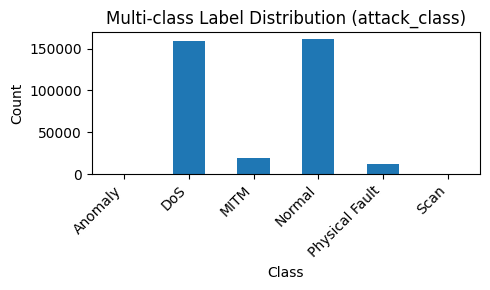


Initial X_multi shape: (352205, 46)

Categorical feature columns:
['protocol', 'source_asset', 'destination_asset']
Final X_multi shape after encoding: (352205, 46)

Multi-class label classes: ['Anomaly' 'DoS' 'MITM' 'Normal' 'Physical Fault' 'Scan']
X_train_m shape: (281764, 46)  X_test_m shape: (70441, 46)
y_train_m distribution: [    69 127162  15269 129170  10072     22]
y_test_m distribution : [   18 31790  3817 32292  2518     6]

Multi-class classifier Accuracy: 0.9849
Multi-class classifier Balanced Accuracy: 0.9686

Classification report (multi-class):
                precision    recall  f1-score   support

       Anomaly       1.00      1.00      1.00        18
           DoS       1.00      1.00      1.00     31790
          MITM       0.96      0.94      0.95      3817
        Normal       0.98      0.98      0.98     32292
Physical Fault       0.86      0.89      0.88      2518
          Scan       1.00      1.00      1.00         6

      accuracy                       

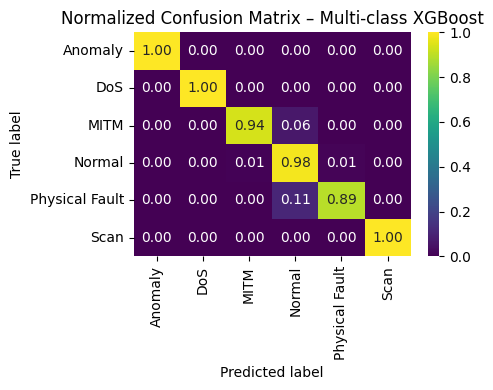

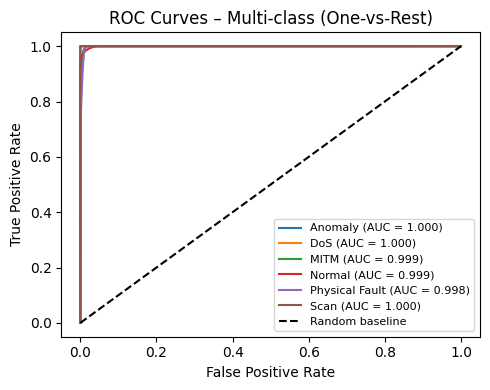


Top 20 features by importance (multi-class model):
              feature  importance
19      tcp_syn_ratio    0.242130
38        mp_nodes_1m    0.217928
39        mp_edges_1m    0.083416
30       mac_nodes_1m    0.069414
31       mac_edges_1m    0.052889
41      mp_density_1m    0.043145
36  mac_avg_degree_5m    0.032375
32  mac_avg_degree_1m    0.031791
37     mac_density_5m    0.030508
33     mac_density_1m    0.028524
34       mac_nodes_5m    0.024909
35       mac_edges_5m    0.021077
28          avg_value    0.013821
42        mp_nodes_5m    0.011003
20      tcp_ack_ratio    0.010527
40   mp_avg_degree_1m    0.010090
45      mp_density_5m    0.009651
43        mp_edges_5m    0.009142
44   mp_avg_degree_5m    0.008500
26          min_value    0.008408


<Figure size 800x500 with 0 Axes>

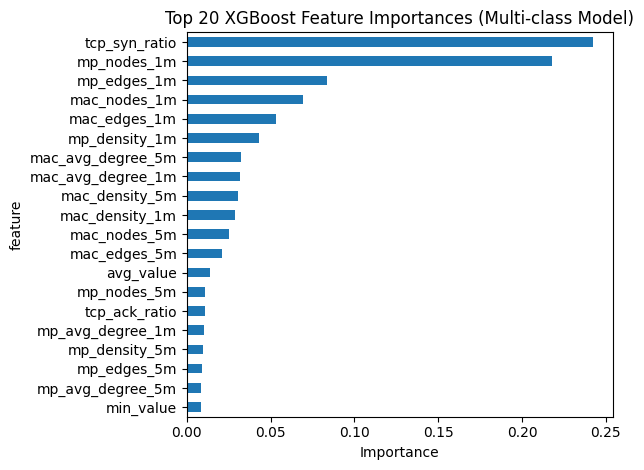

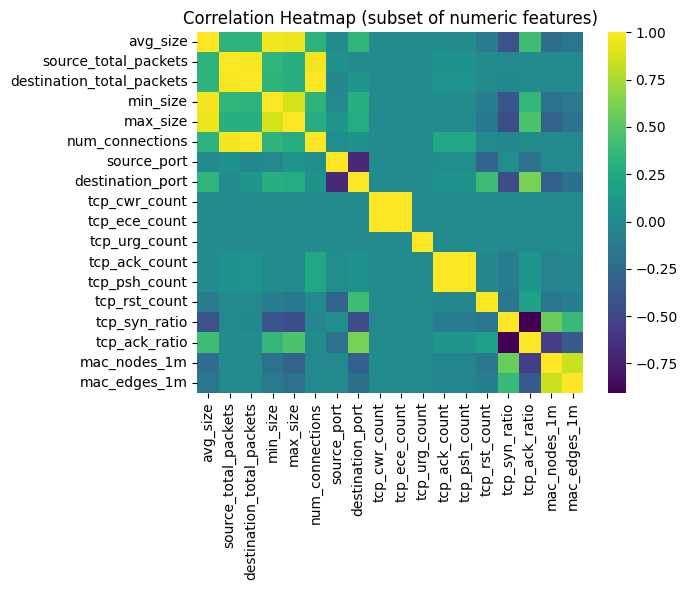

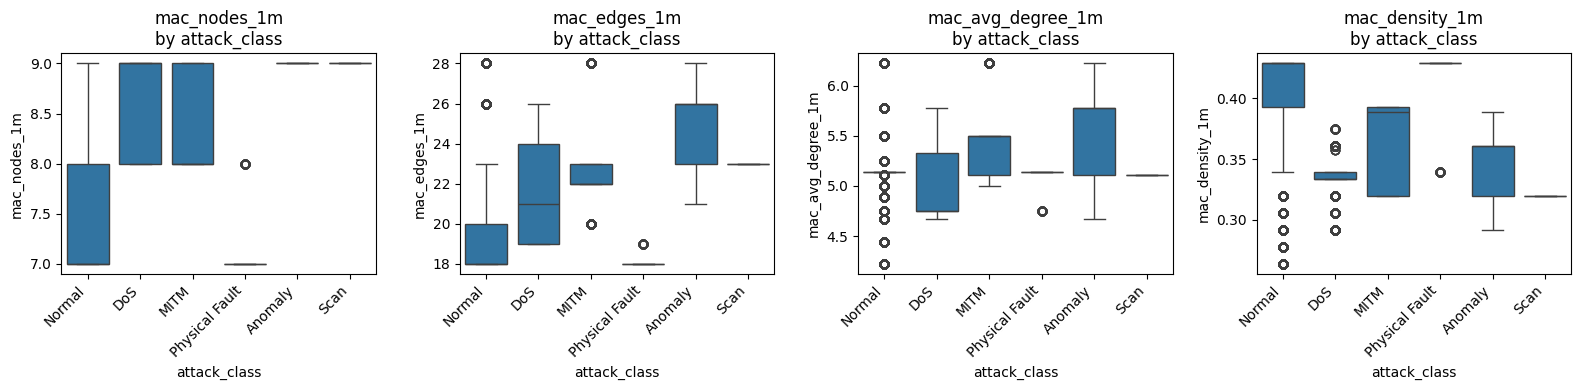

In [18]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    roc_curve,
    auc,
)

import xgboost as xgb


print("combinedDf shape:", combinedDf.shape)
print("\nColumns:")
print(combinedDf.columns.tolist())

print("\nDataFrame info:")
combinedDf.info()

print("\nDtypes (sorted):")
print(combinedDf.dtypes.sort_index())


if "attack_class" not in combinedDf.columns:
    raise ValueError("attack_class column not found – make sure you ran the mapping cell.")

print("\nattack_class value counts:")
class_counts = combinedDf["attack_class"].value_counts().sort_index()
print(class_counts)

plt.figure(figsize=(5,3))
class_counts.plot(kind="bar")
plt.title("Multi-class Label Distribution (attack_class)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


y_multi = combinedDf["attack_class"].copy()

drop_cols_multi = [
    "bucket",
    "attack_types",
    "attack_class",
    "binary_attack",
    "num_attacks",
    "label",
    "label_n",
    "source_ip", "destination_ip",
    "source_mac", "destination_mac",
    "source_key", "destination_key",
    "system_id",
]

X_multi = combinedDf.drop(columns=[c for c in drop_cols_multi if c in combinedDf.columns])

print("\nInitial X_multi shape:", X_multi.shape)


cat_cols_multi = X_multi.select_dtypes(include=["object"]).columns.tolist()
label_encoders_multi = {}

print("\nCategorical feature columns:")
print(cat_cols_multi)

for col in cat_cols_multi:
    le = LabelEncoder()
    X_multi[col] = le.fit_transform(X_multi[col].astype(str))
    label_encoders_multi[col] = le

print("Final X_multi shape after encoding:", X_multi.shape)


le_y_multi = LabelEncoder()
y_multi_enc = le_y_multi.fit_transform(y_multi)

print("\nMulti-class label classes:", le_y_multi.classes_)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y_multi_enc,
    test_size=0.2,
    stratify=y_multi_enc,
    random_state=42,
)

print("X_train_m shape:", X_train_m.shape, " X_test_m shape:", X_test_m.shape)
print("y_train_m distribution:", np.bincount(y_train_m))
print("y_test_m distribution :", np.bincount(y_test_m))


xgb_multi = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    objective="multi:softmax",
    eval_metric="mlogloss",
    n_jobs=-1,
)

xgb_multi.fit(X_train_m, y_train_m)

y_pred_m = xgb_multi.predict(X_test_m)

acc_m = accuracy_score(y_test_m, y_pred_m)
bal_acc_m = balanced_accuracy_score(y_test_m, y_pred_m)

print(f"\nMulti-class classifier Accuracy: {acc_m:.4f}")
print(f"Multi-class classifier Balanced Accuracy: {bal_acc_m:.4f}\n")

print("Classification report (multi-class):")
print(classification_report(y_test_m, y_pred_m, target_names=le_y_multi.classes_))


labels = np.arange(len(le_y_multi.classes_))
cm_m = confusion_matrix(y_test_m, y_pred_m, labels=labels)
cm_norm_m = cm_m.astype(float) / cm_m.sum(axis=1, keepdims=True)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_norm_m,
    annot=True, fmt=".2f",
    xticklabels=le_y_multi.classes_,
    yticklabels=le_y_multi.classes_,
    cmap="viridis"
)
plt.title("Normalized Confusion Matrix – Multi-class XGBoost")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


y_score_m = xgb_multi.predict_proba(X_test_m)

y_test_bin = label_binarize(y_test_m, classes=labels) 
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(5,4))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_m[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{le_y_multi.classes_[i]} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], "k--", label="Random baseline")
plt.title("ROC Curves – Multi-class (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


importances = xgb_multi.feature_importances_
feat_names = X_multi.columns

feat_imp_df = pd.DataFrame({
    "feature": feat_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop 20 features by importance (multi-class model):")
print(feat_imp_df.head(20))

plt.figure(figsize=(8,5))
feat_imp_df.head(20).iloc[::-1].plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False
)
plt.title("Top 20 XGBoost Feature Importances (Multi-class Model)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

numeric_cols = [
    c for c in X_multi.columns
    if np.issubdtype(X_multi[c].dtype, np.number)
]


subset_numeric = [
    "avg_size",
    "source_total_packets",
    "destination_total_packets",
    "min_size",
    "max_size",
    "num_connections",
    "source_port",
    "destination_port",
    "tcp_cwr_count",
    "tcp_ece_count",
    "tcp_urg_count",
    "tcp_ack_count",
    "tcp_psh_count",
    "tcp_rst_count",
    "tcp_syn_ratio",
    "tcp_ack_ratio",
    "mac_nodes_1m",
    "mac_edges_1m",
]

subset_numeric = [c for c in subset_numeric if c in X_multi.columns]

corr = X_multi[subset_numeric].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, cmap="viridis", xticklabels=subset_numeric, yticklabels=subset_numeric)
plt.title("Correlation Heatmap (subset of numeric features)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


graph_metric_cols = [
    "mac_nodes_1m", "mac_edges_1m", "mac_avg_degree_1m", "mac_density_1m",
]

graph_metric_cols = [c for c in graph_metric_cols if c in combinedDf.columns]

if graph_metric_cols:
   
    sample_df = combinedDf.copy()
    if len(sample_df) > 50000:
        sample_df = sample_df.sample(n=50000, random_state=42)

    n_metrics = len(graph_metric_cols)
    plt.figure(figsize=(4*n_metrics, 4))
    for i, col in enumerate(graph_metric_cols, start=1):
        plt.subplot(1, n_metrics, i)
        sns.boxplot(
            data=sample_df,
            x="attack_class",
            y=col
        )
        plt.title(f"{col}\nby attack_class")
        plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("\nNo graph_metric_cols found for boxplots.")
